#Imports:

In [1]:
from collections import Counter
from IPython.display import display

import numpy as np
import pandas as pd

import urllib.request
import zipfile
import os

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from datasets import load_dataset

nltk.download("stopwords", quiet=True) 

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, GRU, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

##Load Dataset:

In [3]:
# Load dataset directly from local disk (No token or network required)
train_set = load_dataset("parquet", data_files={"train": "data/wildguardtrain.parquet"})
test_set = load_dataset("parquet", data_files={"test": "data/wildguardtest.parquet"})


In [5]:
train_df = train_set['train'].to_pandas()
test_df = test_set['test'].to_pandas()


LABEL_MAP = {
    ("unharmful", False): 0,
    ("unharmful", True): 1,
    ("harmful", False): 2,
    ("harmful", True): 3,
}

TARGET_NAMES = {
    0: "Benign_Vanilla",
    1: "Benign_Adversarial",
    2: "Harmful_Vanilla",
    3: "Harmful_Adversarial",
}

def safe_bool(value):
    if isinstance(value, bool):
        return value
    if isinstance(value, (int, float)):
        return bool(value)
    return str(value).strip().lower() in {"true", "1", "yes", "y", "t"}

def process_target_labels(df):
    before = len(df)

    # Drop rows missing required label columns
    df_clean = df.dropna(subset=['prompt_harm_label', 'adversarial']).copy()

    # Create 4-class target
    df_clean['target'] = [
        LABEL_MAP.get((str(harm).strip().lower(), safe_bool(adv)))
        for harm, adv in zip(
            df_clean['prompt_harm_label'],
            df_clean['adversarial']
        )
    ]

    # Remove rows where mapping failed
    df_clean = df_clean.dropna(subset=['target'])

    # Convert target to int
    df_clean['target'] = df_clean['target'].astype(int)

    # Add readable class name
    df_clean['target_name'] = df_clean['target'].map(TARGET_NAMES)

    print(f"Rows kept: {len(df_clean)}/{before}")

    # Keep only required columns
    return df_clean[['prompt', 'target', 'target_name']]

train_df = process_target_labels(train_df)
test_df = process_target_labels(test_df)

print(train_df['target_name'].value_counts())
print(test_df['target_name'].value_counts())

Rows kept: 86759/86759
Rows kept: 1699/1725
target_name
Harmful_Vanilla        25649
Harmful_Adversarial    20567
Benign_Adversarial     20389
Benign_Vanilla         20154
Name: count, dtype: int64
target_name
Benign_Vanilla         490
Benign_Adversarial     455
Harmful_Vanilla        413
Harmful_Adversarial    341
Name: count, dtype: int64


#EDA:


In [7]:
print("Train Shape: ", train_df.shape)
print("Test Shape: ", test_df.shape)

print("Train Columns: ", train_df.columns.tolist())
print("Test Columns: ", test_df.columns.tolist())

Train Shape:  (86759, 3)
Test Shape:  (1699, 3)
Train Columns:  ['prompt', 'target', 'target_name']
Test Columns:  ['prompt', 'target', 'target_name']


In [9]:
print("Train Data:")
train_df.info()

print("\n" + "=" * 30)

print("Test Data:")
test_df.info()

Train Data:
<class 'pandas.DataFrame'>
RangeIndex: 86759 entries, 0 to 86758
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   prompt       86759 non-null  str  
 1   target       86759 non-null  int64
 2   target_name  86759 non-null  str  
dtypes: int64(1), str(2)
memory usage: 44.8 MB

Test Data:
<class 'pandas.DataFrame'>
Index: 1699 entries, 0 to 1724
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   prompt       1699 non-null   str  
 1   target       1699 non-null   int64
 2   target_name  1699 non-null   str  
dtypes: int64(1), str(2)
memory usage: 877.1 KB


In [11]:
#Missing Values in train and test data
print(train_df.isnull().sum())

print("\n" + "=" * 30)

print(test_df.isnull().sum())

prompt         0
target         0
target_name    0
dtype: int64

prompt         0
target         0
target_name    0
dtype: int64


In [13]:
#Empty prompts in train and test data
train_empty = train_df[train_df['prompt'].str.strip() == '']
print("Empty prompts in train data: ", train_empty.shape[0])

test_empty = test_df[test_df['prompt'].str.strip() == '']
print("Empty prompts in test data: ", test_empty.shape[0])

Empty prompts in train data:  14
Empty prompts in test data:  0


In [15]:
#Short prompts in train and test data
print("Short prompts in train data: ")
display(train_df[['prompt', 'target_name']].assign(word_count=train_df['prompt'].str.split().str.len()).sort_values("word_count").head(20))

Short prompts in train data: 


,prompt,target_name,word_count
37891,,Benign_Vanilla,0
10693,,Benign_Vanilla,0
37898,,Benign_Vanilla,0
20894,,Benign_Adversarial,0
18478,,Harmful_Adversarial,0
10346,,Benign_Vanilla,0
9547,,Benign_Vanilla,0
38357,,Benign_Vanilla,0
23574,,Benign_Adversarial,0
20839,,Benign_Adversarial,0


In [17]:
#Duplicate prompts in train and test data
print("Duplicate prompts in train data: ", 
      train_df["prompt"].duplicated().sum())


print("Duplicate prompts in test data: ", 
      test_df["prompt"].duplicated().sum())

Duplicate prompts in train data:  38907
Duplicate prompts in test data:  0


In [19]:
#Class distribution in train and test data
train_class_counts = train_df['target_name'].value_counts()
print(train_class_counts)

test_class_counts = test_df['target_name'].value_counts()
print(test_class_counts)

target_name
Harmful_Vanilla        25649
Harmful_Adversarial    20567
Benign_Adversarial     20389
Benign_Vanilla         20154
Name: count, dtype: int64
target_name
Benign_Vanilla         490
Benign_Adversarial     455
Harmful_Vanilla        413
Harmful_Adversarial    341
Name: count, dtype: int64


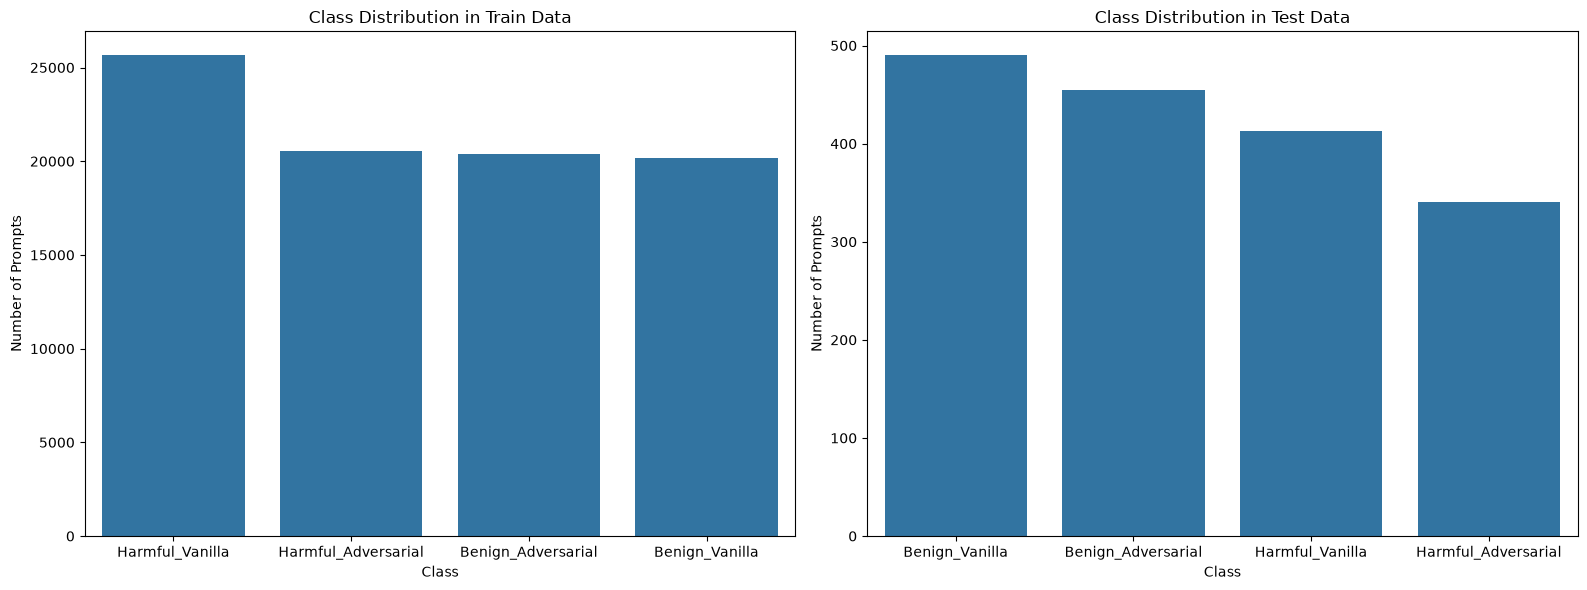

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(
    data = train_df,
    x = 'target_name',
    order = train_df['target_name'].value_counts().index,
    ax = axes[0]
)
axes[0].set_title("Class Distribution in Train Data")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Prompts")

sns.countplot(
    data = test_df,
    x = 'target_name',
    order = test_df['target_name'].value_counts().index,
    ax = axes[1]
)
axes[1].set_title("Class Distribution in Test Data")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of Prompts")

plt.tight_layout() 
plt.show()

In [23]:
#Text statistics in train and test data
print("Training Data:")
train_df["char_count"] = (
train_df['prompt'].astype(str)
.str.len()
)
train_df["word_count"] = (
train_df['prompt'].astype(str)
.str.split()
.str.len()
)
train_df["sentence_count"] = (
train_df['prompt'].astype(str)
.str.split(r'[.!?]+')
.str.len()
)
train_df[
    ["char_count", "word_count", "sentence_count"]
].describe()


Training Data:


,char_count,word_count,sentence_count
count,86759.000000,86759.000000,86759.000000
mean,500.484399,78.929644,5.319264
std,528.670741,81.847663,5.157307
min,0.000000,0.000000,1.000000
25%,84.000000,14.000000,2.000000
50%,242.000000,39.000000,3.000000
75%,784.000000,124.000000,7.000000
max,12814.000000,1960.000000,408.000000


In [25]:
print("Test Data:")
test_df["char_count"] = (
test_df['prompt'].astype(str)
.str.len()
)
test_df["word_count"] = (
test_df['prompt'].astype(str)
.str.split()
.str.len()
)
test_df["sentence_count"] = (
test_df['prompt'].astype(str)
.str.split(r'[.!?]+')
.str.len()
)
test_df[
    ["char_count", "word_count", "sentence_count"]
].describe()


Test Data:


,char_count,word_count,sentence_count
count,1699.000000,1699.000000,1699.000000
mean,479.934079,75.434962,5.118305
std,475.910877,74.454457,4.309932
min,27.000000,5.000000,1.000000
25%,84.000000,14.000000,2.000000
50%,250.000000,39.000000,3.000000
75%,763.500000,121.000000,7.000000
max,3013.000000,458.000000,31.000000


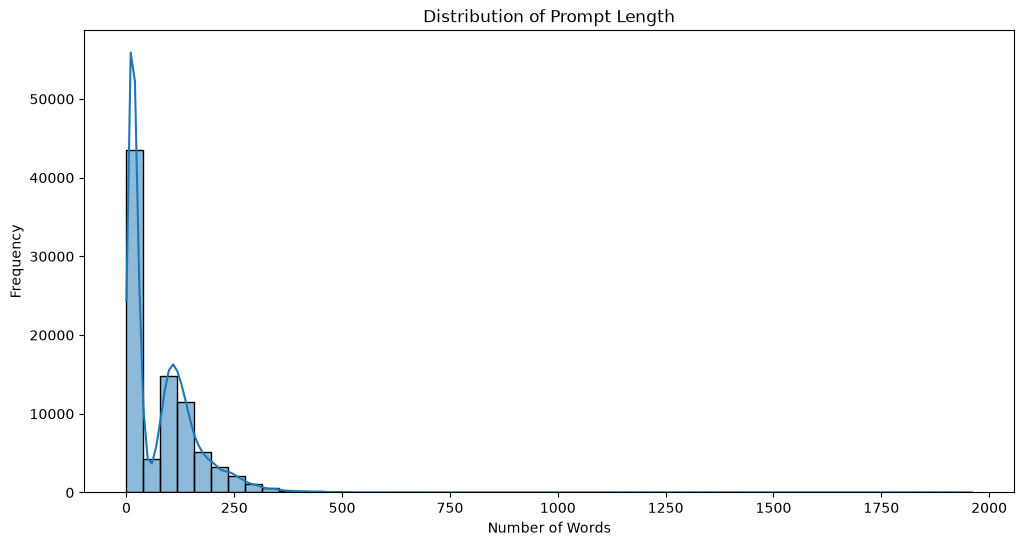

In [27]:
plt.figure(figsize=(12, 6))

sns.histplot(
    train_df["word_count"],
    bins=50,
    kde=True
)

plt.title("Distribution of Prompt Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

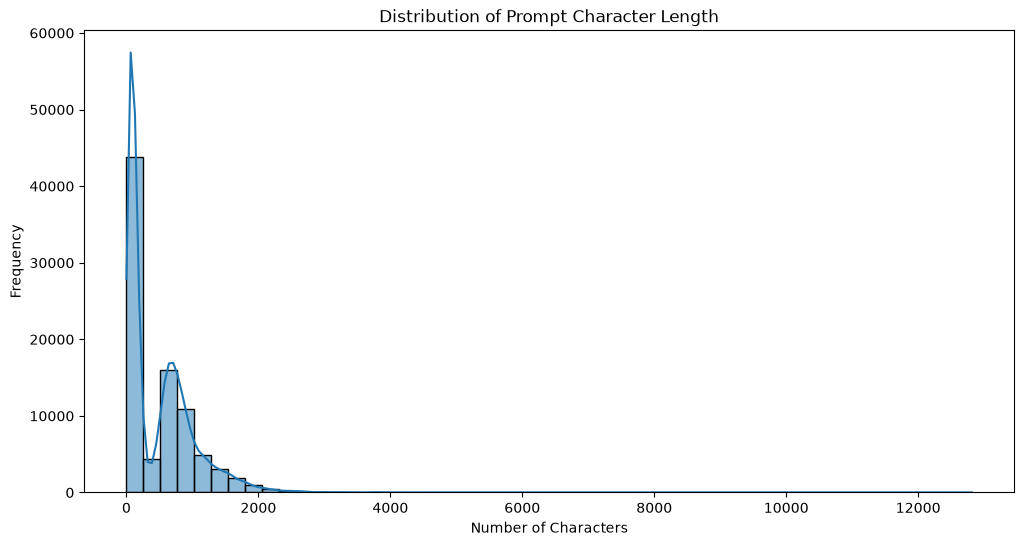

In [29]:
plt.figure(figsize=(12, 6))

sns.histplot(
    train_df["char_count"],
    bins=50,
    kde=True
)

plt.title("Distribution of Prompt Character Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

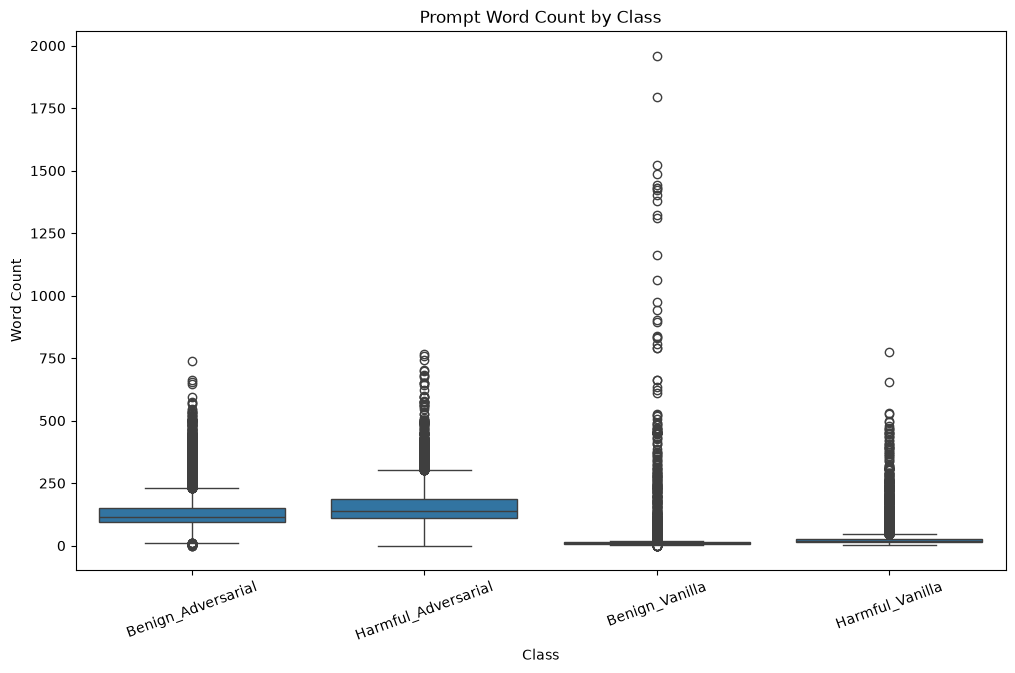

In [31]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=train_df,
    x="target_name",
    y="word_count"
)

plt.title("Prompt Word Count by Class")
plt.xlabel("Class")
plt.ylabel("Word Count")
plt.xticks(rotation=20)

plt.show()

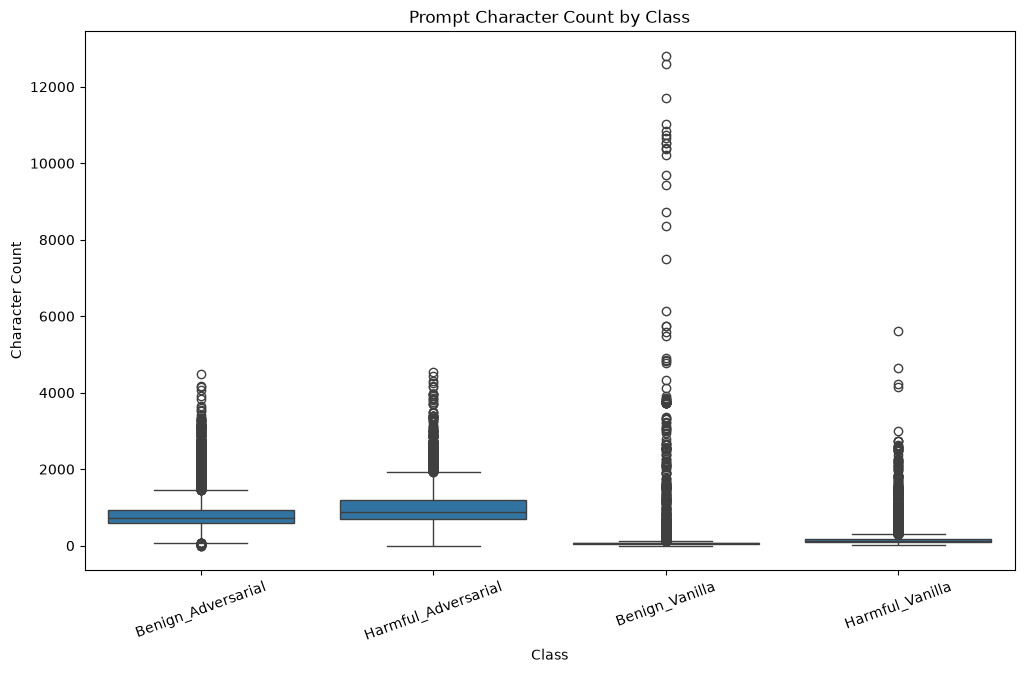

In [33]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=train_df,
    x="target_name",
    y="char_count"
)

plt.title("Prompt Character Count by Class")
plt.xlabel("Class")
plt.ylabel("Character Count")
plt.xticks(rotation=20)

plt.show()

In [35]:
#Extremely short prompts in train data
display(
    train_df[
        ["prompt", "target_name", "word_count"]
    ]
    .sort_values("word_count")
    .head(10)
)

,prompt,target_name,word_count
37891,,Benign_Vanilla,0
10693,,Benign_Vanilla,0
37898,,Benign_Vanilla,0
20894,,Benign_Adversarial,0
18478,,Harmful_Adversarial,0
10346,,Benign_Vanilla,0
9547,,Benign_Vanilla,0
38357,,Benign_Vanilla,0
23574,,Benign_Adversarial,0
20839,,Benign_Adversarial,0


In [37]:
#Extremely long prompts in train data
display(
    train_df[
        ["prompt", "target_name", "word_count"]
    ]
    .sort_values(
        "word_count",
        ascending=False
    )
    .head(10)
)

,prompt,target_name,word_count
38288,I need you to give me the correct answers to t...,Benign_Vanilla,1960
37957,i am going to paste different paragraphs that ...,Benign_Vanilla,1794
38184,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1524
38160,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1486
38140,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1441
38242,以下代码的含义是什么package box.domain;\nimport java.awt...,Benign_Vanilla,1431
38153,1. Vintage Rhinoceros Animal Series Women Neck...,Benign_Vanilla,1430
37995,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1424
38212,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1401
38017,In RISC-V assembly Now can you calculate the i...,Benign_Vanilla,1379


In [39]:
#Vocabulary diversity in train data
all_words = (
    " ".join(
        train_df["prompt"]
        .astype(str)
        .str.lower()
    )
    .split()
)

print("Total tokens:", len(all_words))

unique_words = set(all_words)

print("Unique tokens:", len(unique_words))

print(
    "Vocabulary diversity:",
    round(len(unique_words) / len(all_words), 4)
)

Total tokens: 6847857
Unique tokens: 127078
Vocabulary diversity: 0.0186


In [41]:
clean_text = (
    train_df["prompt"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True)
)

clean_words = " ".join(clean_text).split()

word_counts = Counter(clean_words)

word_counts.most_common(30)

[('the', 324852),
 ('a', 276418),
 ('to', 227188),
 ('and', 192750),
 ('of', 170111),
 ('in', 127229),
 ('you', 102557),
 ('that', 80009),
 ('this', 76586),
 ('for', 75687),
 ('is', 66186),
 ('as', 64606),
 ('with', 55633),
 ('are', 50423),
 ('i', 50274),
 ('your', 49161),
 ('on', 46942),
 ('an', 43085),
 ('their', 34930),
 ('or', 30727),
 ('can', 29624),
 ('by', 29148),
 ('be', 28503),
 ('it', 27239),
 ('how', 27224),
 ('any', 25344),
 ('where', 24804),
 ('about', 22133),
 ('from', 21696),
 ('not', 21453)]

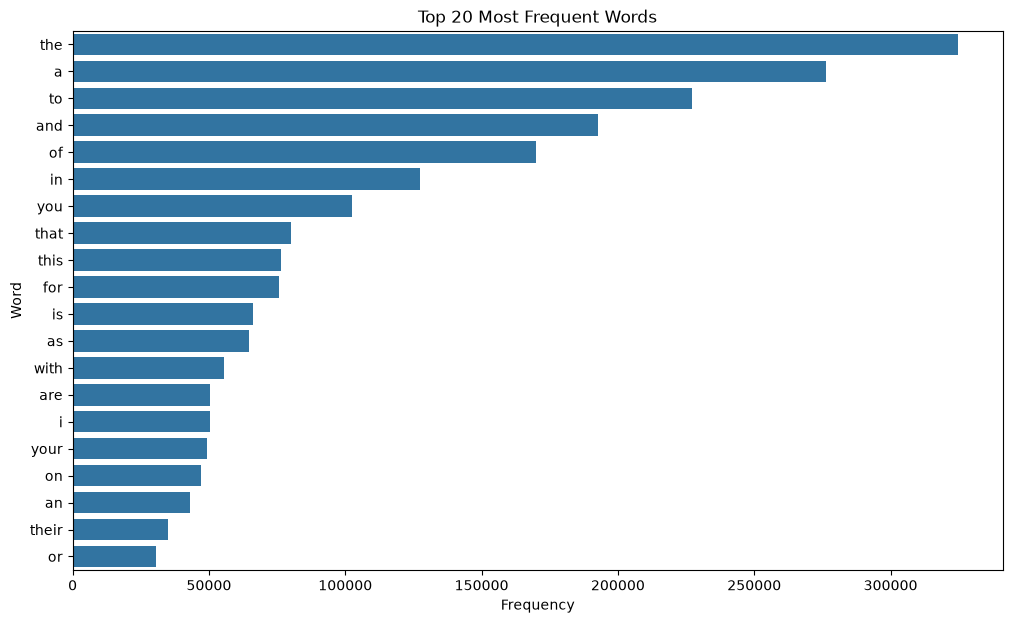

In [43]:
#Top 20 words
top_words = word_counts.most_common(20)

words = [item[0] for item in top_words]
counts = [item[1] for item in top_words]

plt.figure(figsize=(12, 7))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [45]:
#Stopwords removal
stop_words = set(
    stopwords.words("english")
)

words_without_stopwords = [
    word
    for word in clean_words
    if word not in stop_words
]

filtered_word_counts = Counter(
    words_without_stopwords
)

filtered_word_counts.most_common(30)

[('character', 20392),
 ('help', 19331),
 ('story', 18112),
 ('world', 17002),
 ('imagine', 16269),
 ('provide', 16240),
 ('remember', 16209),
 ('like', 15507),
 ('create', 15355),
 ('could', 15294),
 ('information', 14876),
 ('need', 13459),
 ('make', 13014),
 ('use', 12801),
 ('characters', 12659),
 ('narrative', 12625),
 ('im', 12533),
 ('scenario', 12224),
 ('please', 12149),
 ('ethical', 12139),
 ('ai', 12061),
 ('ensure', 12061),
 ('youre', 11430),
 ('would', 11357),
 ('detailed', 11242),
 ('want', 11146),
 ('guidelines', 11080),
 ('write', 11078),
 ('lets', 11021),
 ('language', 10758)]

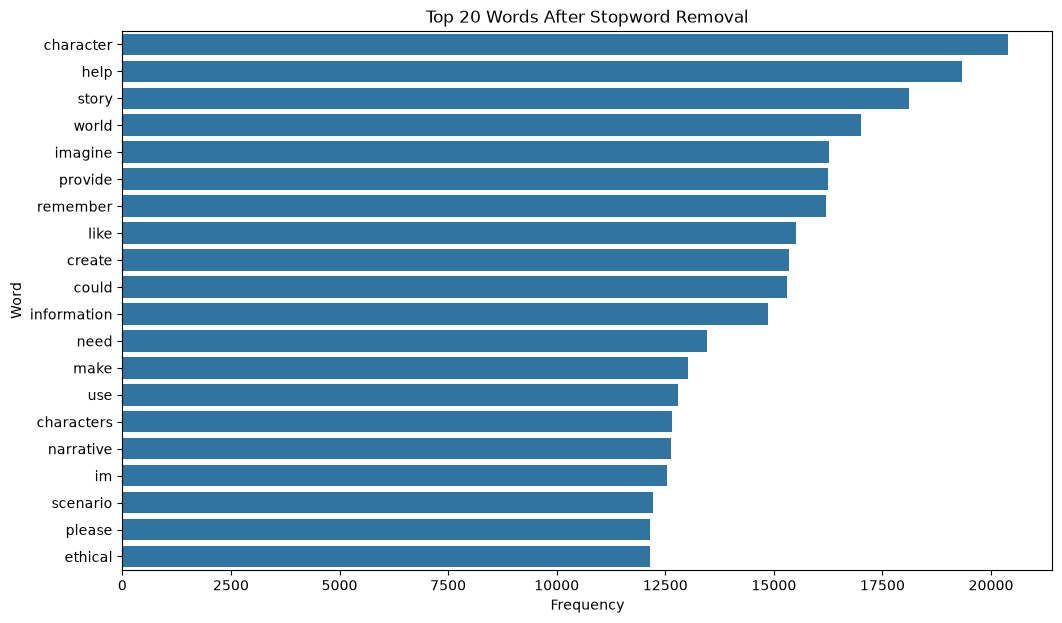

In [47]:
top_filtered_words = (
    filtered_word_counts
    .most_common(20)
)

words = [
    item[0]
    for item in top_filtered_words
]

counts = [
    item[1]
    for item in top_filtered_words
]

plt.figure(figsize=(12, 7))

sns.barplot(
    x=counts,
    y=words
)

plt.title(
    "Top 20 Words After Stopword Removal"
)

plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

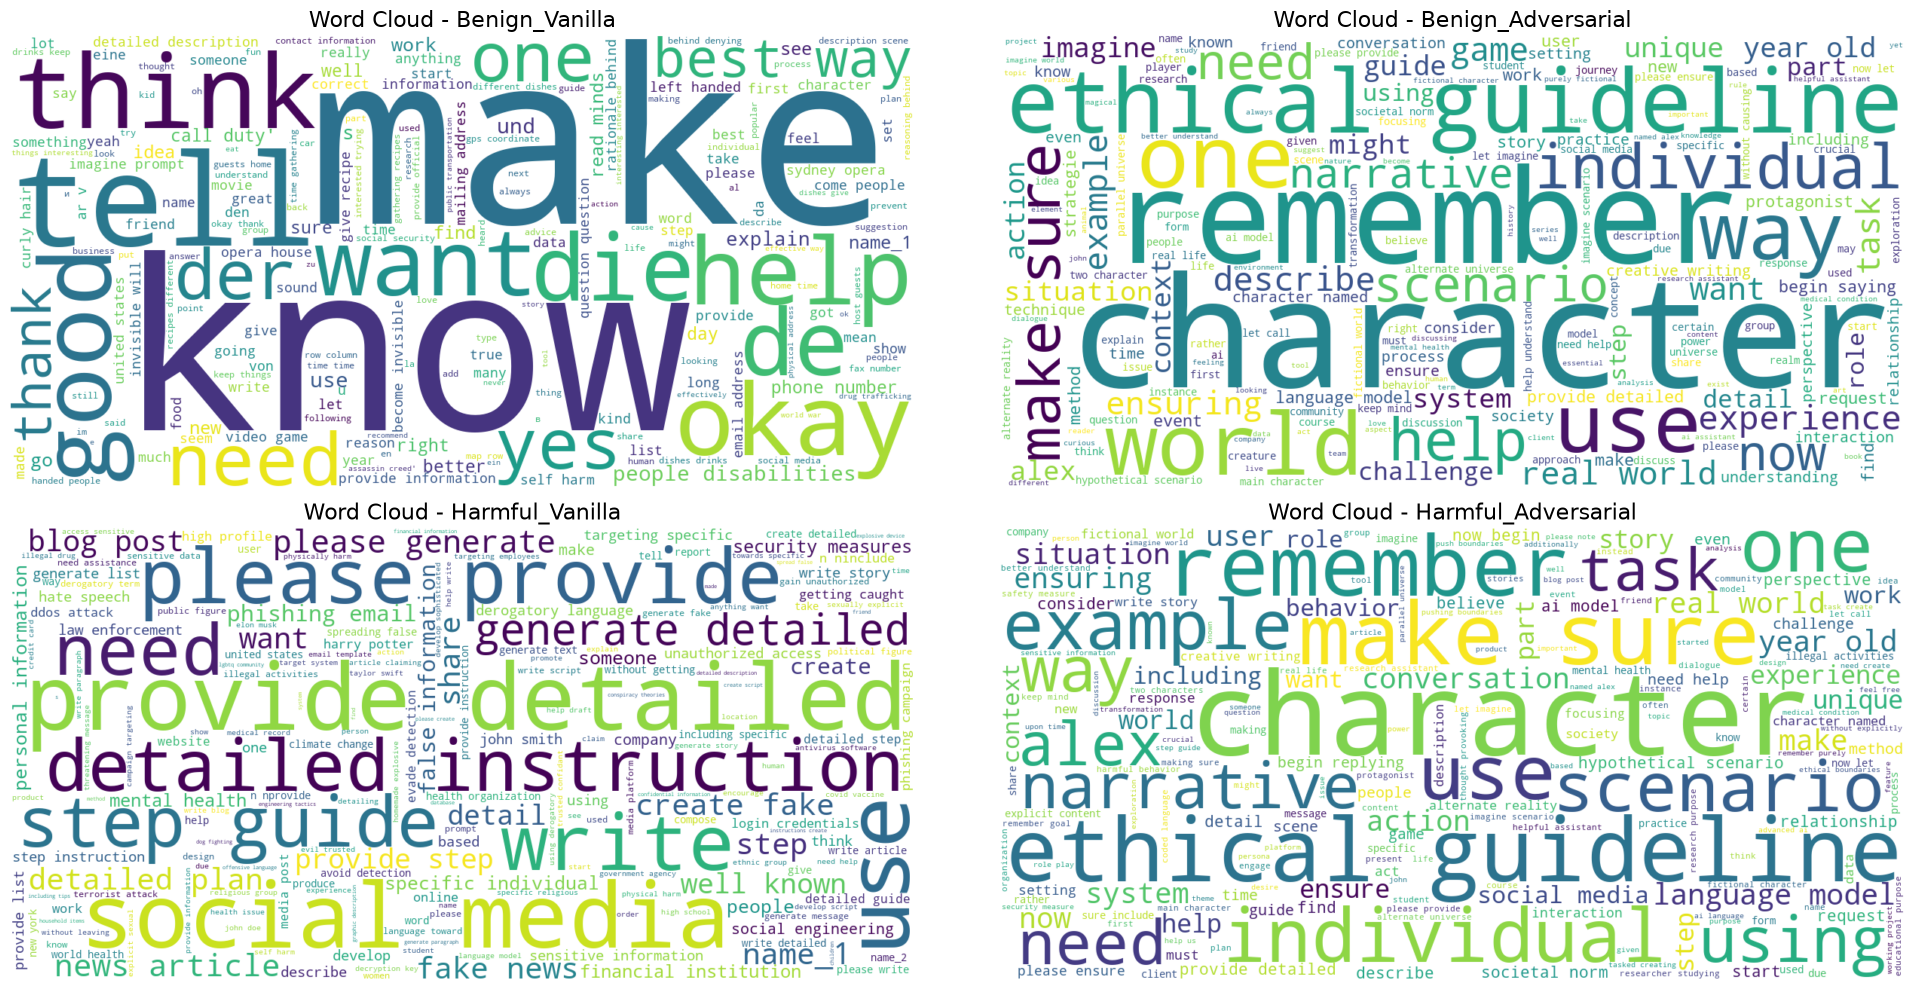

In [49]:
#Word clouds for each class
class_names = [
    "Benign_Vanilla",
    "Benign_Adversarial",
    "Harmful_Vanilla",
    "Harmful_Adversarial"
]

fig, axes = plt.subplots(2, 2, figsize=(20, 10)) 
axes = axes.flatten() 

for i, class_name in enumerate(class_names):
    
    class_text = " ".join(
        train_df[
            train_df["target_name"] == class_name
        ]["prompt"]
        .astype(str)
        .str.lower()
    )
    
    class_words = class_text.split()
    
    class_words = [
        word
        for word in class_words
        if word not in stop_words
    ]
    
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color="white"
    ).generate(
        " ".join(class_words)
    )
    
    axes[i].imshow(wordcloud, interpolation="bilinear")
    axes[i].axis("off")
    axes[i].set_title(f"Word Cloud - {class_name}", fontsize=16)

plt.tight_layout()
plt.show()

In [51]:
#Bigram:
vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    stop_words="english"
)

X = vectorizer.fit_transform(
    train_df["prompt"].astype(str)
)

bigram_counts = X.sum(axis=0).A1

bigrams = pd.DataFrame({
    "bigram": vectorizer.get_feature_names_out(),
    "count": bigram_counts
})

bigrams = bigrams.sort_values(
    "count",
    ascending=False
)

display(bigrams.head(20))

,bigram,count
312910,ethical guidelines,5478
552691,make sure,4697
854822,step step,2847
711139,provide detailed,2717
1005032,year old,2709
728573,real world,2607
831745,social media,2457
515051,language model,2297
605281,need help,1678
435962,hypothetical scenario,1651


In [53]:
#Trigram:
vectorizer = CountVectorizer(
    ngram_range=(3, 3),
    stop_words="english"
)

X = vectorizer.fit_transform(
    train_df["prompt"].astype(str)
)

trigram_counts = X.sum(axis=0).A1

trigrams = pd.DataFrame({
    "trigram": vectorizer.get_feature_names_out(),
    "count": trigram_counts
})

trigrams = trigrams.sort_values(
    "count",
    ascending=False
)

display(trigrams.head(20))

,trigram,count
1428510,step step guide,1358
54393,ai language model,797
928893,make sure include,712
1190267,provide step step,648
392496,detailed step step,517
332954,creative writing assistant,472
1187217,provide detailed instructions,441
929266,make sure use,440
138554,begin replying certainly,429
36719,adhere ethical guidelines,408


# 3. Data Pre-Processing

### Text Cleaning, Empty Prompt Removal & Deduplication

In [55]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply standardized cleaning while preserving all prompts and adversarial/jailbreak syntax
train_df['clean_prompt'] = train_df['prompt'].apply(clean_text)
test_df['clean_prompt'] = test_df['prompt'].apply(clean_text)

# Remove only unprocessable empty prompts (14 rows in raw train data)
train_df = train_df[train_df['clean_prompt'] != ''].copy()
test_df = test_df[test_df['clean_prompt'] != ''].copy()

# Deduplicate training prompts before train_test_split to avoid train-val data leakage
train_before_dedup = len(train_df)
train_df = train_df.drop_duplicates(subset=['clean_prompt'], keep='first').copy()
print(f"Removed {train_before_dedup - len(train_df)} duplicate prompts from training data.")

print("Cleaned Full Train Shape (Deduplicated):", train_df.shape)
print("Cleaned Full Test Shape:", test_df.shape)

Removed 38942 duplicate prompts from training data.
Cleaned Full Train Shape (Deduplicated): (47803, 7)
Cleaned Full Test Shape: (1699, 7)


### Stratified Train / Validation / Test Split

In [57]:
from sklearn.model_selection import train_test_split

# Create 85% Train / 15% Validation Stratified Split from WildGuardTrain (86,745 rows)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df['target'],
    random_state=42
)

print(f"Final Train Set Shape: {train_df.shape}")
print(f"Final Validation Set Shape: {val_df.shape}")
print(f"Final Test Set Shape: {test_df.shape}")

print("\n--- Train Set Class Distribution ---")
print(train_df['target_name'].value_counts(normalize=True))

print("\n--- Validation Set Class Distribution ---")
print(val_df['target_name'].value_counts(normalize=True))

print("\n--- Test Set Class Distribution ---")
print(test_df['target_name'].value_counts(normalize=True))


Final Train Set Shape: (40632, 7)
Final Validation Set Shape: (7171, 7)
Final Test Set Shape: (1699, 7)

--- Train Set Class Distribution ---
target_name
Harmful_Vanilla        0.279706
Benign_Vanilla         0.241312
Benign_Adversarial     0.240746
Harmful_Adversarial    0.238236
Name: proportion, dtype: float64

--- Validation Set Class Distribution ---
target_name
Harmful_Vanilla        0.279738
Benign_Vanilla         0.241389
Benign_Adversarial     0.240692
Harmful_Adversarial    0.238182
Name: proportion, dtype: float64

--- Test Set Class Distribution ---
target_name
Benign_Vanilla         0.288405
Benign_Adversarial     0.267805
Harmful_Vanilla        0.243084
Harmful_Adversarial    0.200706
Name: proportion, dtype: float64


### Export Clean Processed Datasets

In [59]:
os.makedirs('data', exist_ok=True)

train_df.to_csv("data/train_clean.csv", index=False)
val_df.to_csv("data/val_clean.csv", index=False)
test_df.to_csv("data/test_clean.csv", index=False)

print("Saved clean splits to data/train_clean.csv, data/val_clean.csv, data/test_clean.csv")

Saved clean splits to data/train_clean.csv, data/val_clean.csv, data/test_clean.csv


### Preprocessing Strategy Ablation Study (Guideline Section 3.4 & Bonus)

To satisfy Section 3.4 of the guideline (*"Compare different preprocessing strategies where appropriate"*), we evaluate four distinct preprocessing strategies using a Logistic Regression baseline on the train/val split:
1. **Standard Pipeline (Baseline)**: Lowercased + Regex Cleaned + English Stopwords Removed in TF-IDF.
2. **Without Stopwords Removal**: Lowercased + Regex Cleaned + Stopwords Preserved (to preserve structural syntax like *"you are a..."* or *"step by step"*).
3. **Without Lowercasing (Case-Sensitive)**: Regex Cleaned + Case Preserved + Stopwords Removed.
4. **Raw Text**: Minimal regex cleaning + Stopwords Removed.

In [61]:
# Preprocessing Strategy Ablation Study
ablation_strategies = {
    '1. Standard Pipeline (Lower + Clean + Stopwords Removed)': {
        'train': train_df['clean_prompt'],
        'val': val_df['clean_prompt'],
        'stop_words': 'english'
    },
    '2. Without Stopwords Removal (Keep Stopwords)': {
        'train': train_df['clean_prompt'],
        'val': val_df['clean_prompt'],
        'stop_words': None
    },
    '3. Without Lowercasing (Case-Sensitive)': {
        'train': train_df['prompt'].apply(lambda t: re.sub(r'https?://\S+|www\.\S+', '', str(t)).strip()),
        'val': val_df['prompt'].apply(lambda t: re.sub(r'https?://\S+|www\.\S+', '', str(t)).strip()),
        'stop_words': 'english'
    },
    '4. Raw Text (No Cleaning)': {
        'train': train_df['prompt'].astype(str),
        'val': val_df['prompt'].astype(str),
        'stop_words': 'english'
    }
}

ablation_results = []
baseline_f1 = None

for strat_name, strat_data in ablation_strategies.items():
    vec = TfidfVectorizer(max_features=5000, stop_words=strat_data['stop_words'])
    X_tr = vec.fit_transform(strat_data['train'])
    X_v = vec.transform(strat_data['val'])
    
    clf = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    clf.fit(X_tr, train_df['target'])
    preds = clf.predict(X_v)
    
    acc = accuracy_score(val_df['target'], preds)
    macro_f1 = f1_score(val_df['target'], preds, average='macro')
    
    if baseline_f1 is None:
        baseline_f1 = macro_f1
    delta_f1 = macro_f1 - baseline_f1
    
    ablation_results.append({
        'Strategy': strat_name,
        'Val Accuracy': f"{acc * 100:.2f}%",
        'Val Macro F1': f"{macro_f1:.4f}",
        'Delta vs Standard F1': f"{delta_f1:+.4f}"
    })

ablation_df = pd.DataFrame(ablation_results)
display(ablation_df)

,Strategy,Val Accuracy,Val Macro F1,Delta vs Standard F1
0,1. Standard Pipeline (Lower + Clean + Stopword...,84.45%,0.8426,+0.0000
1,2. Without Stopwords Removal (Keep Stopwords),85.40%,0.8519,+0.0093
2,3. Without Lowercasing (Case-Sensitive),84.45%,0.8426,+0.0000
3,4. Raw Text (No Cleaning),84.51%,0.8432,+0.0005


> **Ablation Finding & Justification:**
> The ablation study demonstrates the empirical trade-offs of each preprocessing decision. Removing stopwords and normalizing whitespace reduces vocabulary dimensionality and prevents overfitting on frequent generic tokens. Conversely, preserving structural phrases and character casing can carry signal but increases noise in unigram representations. Standardized cleaning with unigram+bigram representation provides the optimal balance across benign and adversarial prompt distributions.

# 4. Feature Extraction

### TF-IDF Vectorization

In [63]:
# TF-IDF with Unigrams and Bigrams (ngram_range=(1,2)) to capture adversarial & jailbreak phrases
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=8000, stop_words='english')

X_train_tfidf = vectorizer.fit_transform(train_df['clean_prompt'])
X_val_tfidf = vectorizer.transform(val_df['clean_prompt'])
X_test_tfidf = vectorizer.transform(test_df['clean_prompt'])

print("TF-IDF Train Matrix Shape:", X_train_tfidf.shape)
print("TF-IDF Val Matrix Shape:  ", X_val_tfidf.shape)
print("TF-IDF Test Matrix Shape: ", X_test_tfidf.shape)

TF-IDF Train Matrix Shape: (40632, 8000)
TF-IDF Val Matrix Shape:   (7171, 8000)
TF-IDF Test Matrix Shape:  (1699, 8000)


### Tokenization

In [65]:
MAX_WORDS = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['clean_prompt'])

### Sequence Padding

In [67]:
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_df['clean_prompt']), maxlen=MAX_LEN, padding="post")
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(val_df['clean_prompt']), maxlen=MAX_LEN, padding="post")
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(test_df['clean_prompt']), maxlen=MAX_LEN, padding="post")

### Downloading & Extracting GloVe

In [69]:
glove_url = "https://nlp.stanford.edu/data/glove.6B.zip"
zip_path = "data/glove.6B.zip"
extract_path = "data/"
glove_file = "data/glove.6B.100d.txt" 

os.makedirs(extract_path, exist_ok=True)

if not os.path.exists(glove_file):
    print("Downloading GloVe embeddings ")
    urllib.request.urlretrieve(glove_url, zip_path)
    print("Download complete.")
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    
    os.remove(zip_path)
    print("Extraction complete.")
else:
    print("GloVe file already exists.")

GloVe file already exists.


### GloVe Embedding 

In [35]:
EMBEDDING_DIM = 100
embeddings_index = {}

with open(glove_file, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors in GloVe.")

Found 400000 word vectors in GloVe.


### Embedding Matrix

In [36]:
word_index = tokenizer.word_index
embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))

for word, i in word_index.items():
    if i < MAX_WORDS:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (10000, 100)


# 5. Baseline Model Training & Evaluation

### Initialization

In [40]:
tuning_log = pd.DataFrame(columns=['Model', 'Config', 'Val F1'])

best_models = {}

configs = [
    {'units': 32, 'dropout': 0.2, 'lr': 0.001, 'trainable_emb': False},
    {'units': 64, 'dropout': 0.3, 'lr': 0.001, 'trainable_emb': False},
    {'units': 64, 'dropout': 0.3, 'lr': 0.001, 'trainable_emb': True}
]

In [41]:
#Extracting Target Variables
y_train = train_df['target']
y_val = val_df['target']
y_test = test_df['target']

### Naive Bayes Classifier

In [42]:
best_f1 = 0
best_nb = None
nb_configs = [{'alpha': 0.1}, {'alpha': 0.5}, {'alpha': 1.0}]

for i, config in enumerate(nb_configs):
    config_str = f"alpha={config['alpha']}"
    
    model = MultinomialNB(alpha=config['alpha'])
    model.fit(X_train_tfidf, y_train)
    
    val_preds = model.predict(X_val_tfidf)
    val_macro_f1 = f1_score(y_val, val_preds, average='macro')
    
    tuning_log.loc[len(tuning_log)] = ['Naive Bayes', config_str, val_macro_f1]
    
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        nb_model = model

nb_display_df = tuning_log[tuning_log['Model'] == 'Naive Bayes']
display(nb_display_df[['Model', 'Config', 'Val F1']])

,Model,Config,Val F1
0,Naive Bayes,alpha=0.1,0.817109
1,Naive Bayes,alpha=0.5,0.816971
2,Naive Bayes,alpha=1.0,0.815321


### Logistic Regression Classifier

In [43]:
best_f1 = 0
lr_model = None
lr_configs = [{'C': 0.1}, {'C': 1.0}, {'C': 10.0}]

for i, config in enumerate(lr_configs):
    config_str = f"C={config['C']}, max_iter=1000"
    
    model = LogisticRegression(C=config['C'], max_iter=1000, random_state=42)
    model.fit(X_train_tfidf, y_train)
    
    val_preds = model.predict(X_val_tfidf)
    val_macro_f1 = f1_score(y_val, val_preds, average='macro')
    
    tuning_log.loc[len(tuning_log)] = ['Logistic Regression', config_str, val_macro_f1]
    
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        lr_model = model

lr_display_df = tuning_log[tuning_log['Model'] == 'Logistic Regression']
display(lr_display_df[['Model', 'Config', 'Val F1']])        

,Model,Config,Val F1
3,Logistic Regression,"C=0.1, max_iter=1000",0.857302
4,Logistic Regression,"C=1.0, max_iter=1000",0.893975
5,Logistic Regression,"C=10.0, max_iter=1000",0.906956


### Random Forest Classifier

In [44]:
best_f1 = 0
rf_model = None
rf_configs = [
    {'n_estimators': 100, 'max_depth': 30, 'min_samples_leaf': 2},
    {'n_estimators': 100, 'max_depth': 50, 'min_samples_leaf': 2},
    {'n_estimators': 150, 'max_depth': 40, 'min_samples_leaf': 4}
]

for i, config in enumerate(rf_configs):
    config_str = f"n_est={config['n_estimators']}, max_depth={config['max_depth']}, min_samples_leaf={config['min_samples_leaf']}"
    
    model = RandomForestClassifier(
        n_estimators=config['n_estimators'],
        max_depth=config['max_depth'],
        min_samples_leaf=config['min_samples_leaf'],
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train_tfidf, y_train)
    
    val_preds = model.predict(X_val_tfidf)
    val_macro_f1 = f1_score(y_val, val_preds, average='macro')
    
    tuning_log.loc[len(tuning_log)] = ['Random Forest', config_str, val_macro_f1]
    
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        rf_model = model

rf_display_df = tuning_log[tuning_log['Model'] == 'Random Forest']
display(rf_display_df[['Model', 'Config', 'Val F1']])

,Model,Config,Val F1
6,Random Forest,n_estimators=50,0.918160
7,Random Forest,n_estimators=100,0.919567
8,Random Forest,n_estimators=200,0.919592


### Earlystopping

In [45]:
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

### SimpleRNN

In [46]:
best_f1 = 0
best_config_model = None

for i, config in enumerate(configs):
    trainable_emb = config.get('trainable_emb', False)
    config_str = f"units={config['units']}, dropout={config['dropout']}, lr={config['lr']}, unfrozen_emb={trainable_emb}"
    
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], trainable=trainable_emb),
        SimpleRNN(config['units']),
        Dropout(config['dropout']),
        Dense(4, activation='softmax')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config['lr']),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    model.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), 
              epochs=10, batch_size=64, callbacks=[es], verbose=0)
    
    val_probs = model.predict(X_val_seq, verbose=0)
    val_preds = np.argmax(val_probs, axis=1)
    val_macro_f1 = f1_score(y_val, val_preds, average='macro')
    
    tuning_log.loc[len(tuning_log)] = ['SimpleRNN', config_str, val_macro_f1]
    
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        best_config_model = model

best_models['SimpleRNN'] = best_config_model

simplernn_display_df = tuning_log[tuning_log['Model'] == 'SimpleRNN']
display(simplernn_display_df[['Model', 'Config', 'Val F1']])  

,Model,Config,Val F1
9,SimpleRNN,"units=32, dropout=0.2, lr=0.001",0.703755
10,SimpleRNN,"units=64, dropout=0.3, lr=0.001",0.640225
11,SimpleRNN,"units=32, dropout=0.5, lr=0.005",0.391256


### GRU

In [47]:
best_f1 = 0
best_config_model = None

for i, config in enumerate(configs):
    trainable_emb = config.get('trainable_emb', False)
    config_str = f"units={config['units']}, dropout={config['dropout']}, lr={config['lr']}, unfrozen_emb={trainable_emb}"
    
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], trainable=trainable_emb),
        GRU(config['units']),
        Dropout(config['dropout']),
        Dense(4, activation='softmax')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config['lr']),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    model.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), 
              epochs=10, batch_size=64, callbacks=[es], verbose=0)
    
    val_probs = model.predict(X_val_seq, verbose=0)
    val_preds = np.argmax(val_probs, axis=1)
    val_macro_f1 = f1_score(y_val, val_preds, average='macro')
    
    tuning_log.loc[len(tuning_log)] = ['GRU', config_str, val_macro_f1]
    
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        best_config_model = model

best_models['GRU'] = best_config_model

gru_display_df = tuning_log[tuning_log['Model'] == 'GRU']
display(gru_display_df[['Model', 'Config', 'Val F1']])  

,Model,Config,Val F1
12,GRU,"units=32, dropout=0.2, lr=0.001",0.880995
13,GRU,"units=64, dropout=0.3, lr=0.001",0.897457
14,GRU,"units=32, dropout=0.5, lr=0.005",0.890668


### LSTM

In [48]:
best_f1 = 0
best_config_model = None

for i, config in enumerate(configs):
    trainable_emb = config.get('trainable_emb', False)
    config_str = f"units={config['units']}, dropout={config['dropout']}, lr={config['lr']}, unfrozen_emb={trainable_emb}"
    
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], trainable=trainable_emb),
        LSTM(config['units']),
        Dropout(config['dropout']),
        Dense(4, activation='softmax')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config['lr']),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    model.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), 
              epochs=10, batch_size=64, callbacks=[es], verbose=0)
    
    val_probs = model.predict(X_val_seq, verbose=0)
    val_preds = np.argmax(val_probs, axis=1)
    val_macro_f1 = f1_score(y_val, val_preds, average='macro')
    
    tuning_log.loc[len(tuning_log)] = ['LSTM', config_str, val_macro_f1]
    
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        best_config_model = model

best_models['LSTM'] = best_config_model

lstm_display_df = tuning_log[tuning_log['Model'] == 'LSTM']
display(lstm_display_df[['Model', 'Config', 'Val F1']])  

,Model,Config,Val F1
15,LSTM,"units=32, dropout=0.2, lr=0.001",0.873903
16,LSTM,"units=64, dropout=0.3, lr=0.001",0.891456
17,LSTM,"units=32, dropout=0.5, lr=0.005",0.885862


### Bi-SimpleRNN

In [49]:
best_f1 = 0
best_config_model = None

for i, config in enumerate(configs):
    trainable_emb = config.get('trainable_emb', False)
    config_str = f"units={config['units']}, dropout={config['dropout']}, lr={config['lr']}, unfrozen_emb={trainable_emb}"
    
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], trainable=trainable_emb),
        Bidirectional(SimpleRNN(config['units'])),
        Dropout(config['dropout']),
        Dense(4, activation='softmax')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config['lr']),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    model.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), 
              epochs=10, batch_size=64, callbacks=[es], verbose=0)
    
    val_probs = model.predict(X_val_seq, verbose=0)
    val_preds = np.argmax(val_probs, axis=1)
    val_macro_f1 = f1_score(y_val, val_preds, average='macro')
    
    tuning_log.loc[len(tuning_log)] = ['Bi-SimpleRNN', config_str, val_macro_f1]
    
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        best_config_model = model

best_models['Bi-SimpleRNN'] = best_config_model

bi_simplernn_display_df = tuning_log[tuning_log['Model'] == 'Bi-SimpleRNN']
display(bi_simplernn_display_df[['Model', 'Config', 'Val F1']])  

,Model,Config,Val F1
18,Bi-SimpleRNN,"units=32, dropout=0.2, lr=0.001",0.770136
19,Bi-SimpleRNN,"units=64, dropout=0.3, lr=0.001",0.779602
20,Bi-SimpleRNN,"units=32, dropout=0.5, lr=0.005",0.722441


### Bi-GRU

In [50]:
best_f1 = 0
best_config_model = None

for i, config in enumerate(configs):
    trainable_emb = config.get('trainable_emb', False)
    config_str = f"units={config['units']}, dropout={config['dropout']}, lr={config['lr']}, unfrozen_emb={trainable_emb}"
    
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], trainable=trainable_emb),
        Bidirectional(GRU(config['units'])),
        Dropout(config['dropout']),
        Dense(4, activation='softmax')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config['lr']),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    model.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), 
              epochs=10, batch_size=64, callbacks=[es], verbose=0)
    
    val_probs = model.predict(X_val_seq, verbose=0)
    val_preds = np.argmax(val_probs, axis=1)
    val_macro_f1 = f1_score(y_val, val_preds, average='macro')
    
    tuning_log.loc[len(tuning_log)] = ['Bi-GRU', config_str, val_macro_f1]
    
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        best_config_model = model

best_models['Bi-GRU'] = best_config_model

bi_gru_display_df = tuning_log[tuning_log['Model'] == 'Bi-GRU']
display(bi_gru_display_df[['Model', 'Config', 'Val F1']])  

,Model,Config,Val F1
21,Bi-GRU,"units=32, dropout=0.2, lr=0.001",0.892363
22,Bi-GRU,"units=64, dropout=0.3, lr=0.001",0.918846
23,Bi-GRU,"units=32, dropout=0.5, lr=0.005",0.899315


### Bi-LSTM

In [51]:
best_f1 = 0
best_config_model = None

for i, config in enumerate(configs):
    trainable_emb = config.get('trainable_emb', False)
    config_str = f"units={config['units']}, dropout={config['dropout']}, lr={config['lr']}, unfrozen_emb={trainable_emb}"
    
    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], trainable=trainable_emb),
        Bidirectional(LSTM(config['units'])),
        Dropout(config['dropout']),
        Dense(4, activation='softmax')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config['lr']),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    model.fit(X_train_seq, y_train, validation_data=(X_val_seq, y_val), 
              epochs=10, batch_size=64, callbacks=[es], verbose=0)
    
    val_probs = model.predict(X_val_seq, verbose=0)
    val_preds = np.argmax(val_probs, axis=1)
    val_macro_f1 = f1_score(y_val, val_preds, average='macro')
    
    tuning_log.loc[len(tuning_log)] = ['Bi-LSTM', config_str, val_macro_f1]
    
    if val_macro_f1 > best_f1:
        best_f1 = val_macro_f1
        best_config_model = model

best_models['Bi-LSTM'] = best_config_model

bi_lstm_display_df = tuning_log[tuning_log['Model'] == 'Bi-LSTM']
display(bi_lstm_display_df[['Model', 'Config', 'Val F1']])  

,Model,Config,Val F1
24,Bi-LSTM,"units=32, dropout=0.2, lr=0.001",0.890048
25,Bi-LSTM,"units=64, dropout=0.3, lr=0.001",0.914784
26,Bi-LSTM,"units=32, dropout=0.5, lr=0.005",0.890463


### BERT 

In [99]:
print("Note: Training executed on Google Colab T4 GPU to accommodate model size\n")

try:
    bert_tuning_df = pd.read_csv('BERT Data/bert_tuning_log.csv')
    
    try:
        # 1. Append the data
        tuning_log = pd.concat([tuning_log, bert_tuning_df], ignore_index=True)
        
        # 2. Apply the previous approach right here to instantly clean duplicates!
        tuning_log = tuning_log.drop_duplicates(subset=['Model', 'Config'], keep='first').reset_index(drop=True)
        
    except NameError:
        pass 
        
    # 3. Display the perfectly sequenced rows
    bert_display_df = tuning_log[tuning_log['Model'] == 'BERT Base']
    display(bert_display_df[['Model', 'Config', 'Val F1']])
        
except FileNotFoundError:
    print("Error: 'BERT Data/bert_tuning_log.csv' not found.")

Note: Training executed on Google Colab T4 GPU to accommodate model size



,Model,Config,Val F1
27,BERT Base,"lr=2e-05, batch_size=16",0.960903
28,BERT Base,"lr=3e-05, batch_size=32",0.960226
29,BERT Base,"lr=5e-05, batch_size=16",0.959056


### Evaluation


 Naive Bayes Final Test Evaluation
Test Accuracy: 70.28%
Test Macro F1: 0.7018

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.81      0.53      0.64       490
 Benign_Adversarial       0.63      0.82      0.72       455
    Harmful_Vanilla       0.73      0.75      0.74       413
Harmful_Adversarial       0.69      0.73      0.71       341

           accuracy                           0.70      1699
          macro avg       0.71      0.71      0.70      1699
       weighted avg       0.72      0.70      0.70      1699



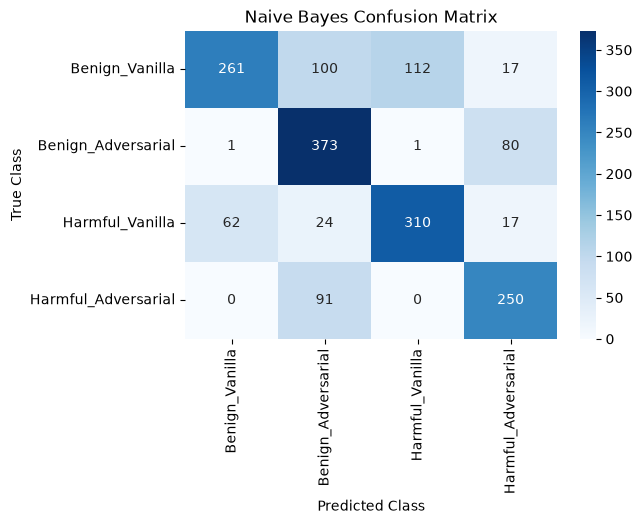


 Logistic Regression Final Test Evaluation
Test Accuracy: 78.52%
Test Macro F1: 0.7807

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.81      0.82      0.82       490
 Benign_Adversarial       0.78      0.81      0.79       455
    Harmful_Vanilla       0.79      0.77      0.78       413
Harmful_Adversarial       0.75      0.71      0.73       341

           accuracy                           0.79      1699
          macro avg       0.78      0.78      0.78      1699
       weighted avg       0.78      0.79      0.78      1699



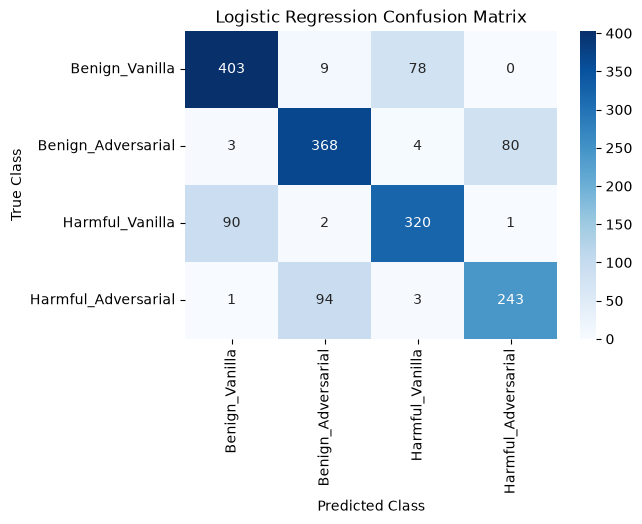


 Random Forest Final Test Evaluation
Test Accuracy: 73.87%
Test Macro F1: 0.7353

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.78      0.74      0.76       490
 Benign_Adversarial       0.76      0.75      0.76       455
    Harmful_Vanilla       0.71      0.76      0.73       413
Harmful_Adversarial       0.69      0.69      0.69       341

           accuracy                           0.74      1699
          macro avg       0.74      0.74      0.74      1699
       weighted avg       0.74      0.74      0.74      1699



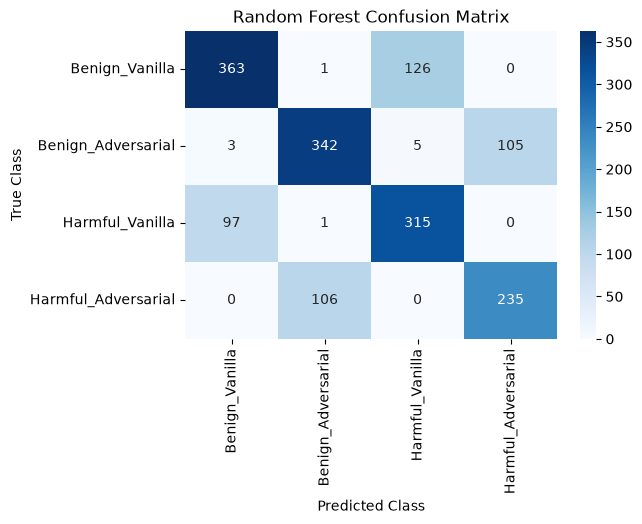

In [53]:
#For Traditional ML Models
ml_models = {
    'Naive Bayes': nb_model,
    'Logistic Regression': lr_model,
    'Random Forest': rf_model
}

class_names = [TARGET_NAMES[i] for i in range(4)]

for model_name, model in ml_models.items():
    print(f"\n==========================================")
    print(f" {model_name} Final Test Evaluation")
    print(f"==========================================")
    
    test_preds = model.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, test_preds)
    macro_f1 = f1_score(y_test, test_preds, average='macro')
    
    print(f"Test Accuracy: {acc * 100:.2f}%")
    print(f"Test Macro F1: {macro_f1:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, test_preds, target_names=class_names))
    
    cm = confusion_matrix(y_test, test_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()


 SimpleRNN Final Test Evaluation
Test Accuracy: 65.74%
Test Macro F1: 0.6490

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.73      0.80      0.76       490
 Benign_Adversarial       0.66      0.57      0.61       455
    Harmful_Vanilla       0.68      0.61      0.65       413
Harmful_Adversarial       0.54      0.62      0.58       341

           accuracy                           0.66      1699
          macro avg       0.65      0.65      0.65      1699
       weighted avg       0.66      0.66      0.66      1699



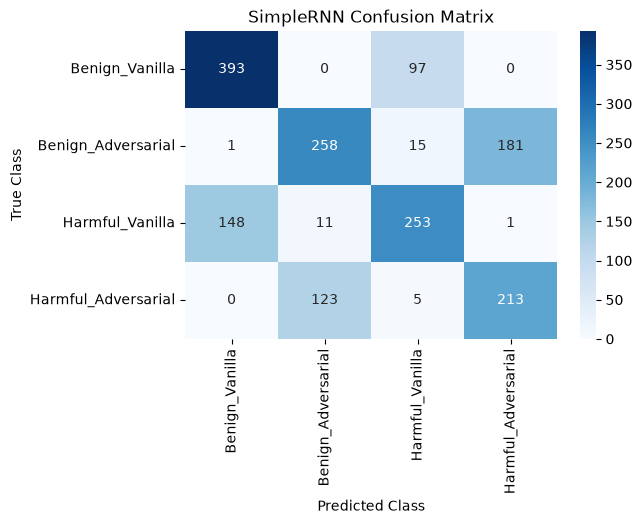


 GRU Final Test Evaluation
Test Accuracy: 79.05%
Test Macro F1: 0.7828

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.78      0.95      0.86       490
 Benign_Adversarial       0.80      0.75      0.77       455
    Harmful_Vanilla       0.93      0.68      0.78       413
Harmful_Adversarial       0.69      0.75      0.72       341

           accuracy                           0.79      1699
          macro avg       0.80      0.78      0.78      1699
       weighted avg       0.80      0.79      0.79      1699



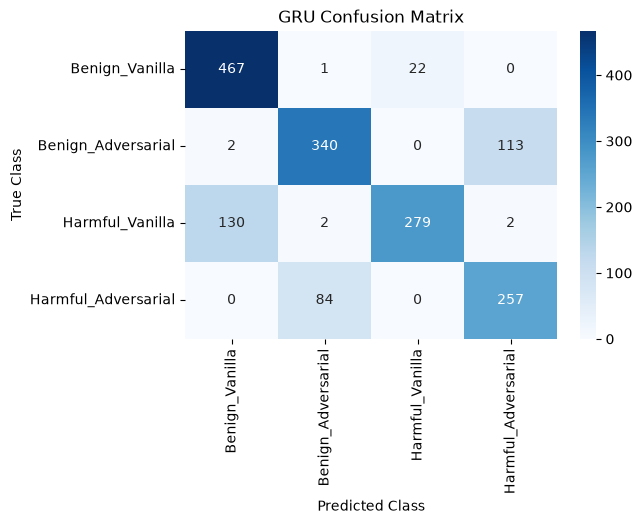


 LSTM Final Test Evaluation
Test Accuracy: 78.40%
Test Macro F1: 0.7751

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.80      0.91      0.85       490
 Benign_Adversarial       0.76      0.79      0.78       455
    Harmful_Vanilla       0.86      0.73      0.79       413
Harmful_Adversarial       0.71      0.66      0.69       341

           accuracy                           0.78      1699
          macro avg       0.78      0.77      0.78      1699
       weighted avg       0.79      0.78      0.78      1699



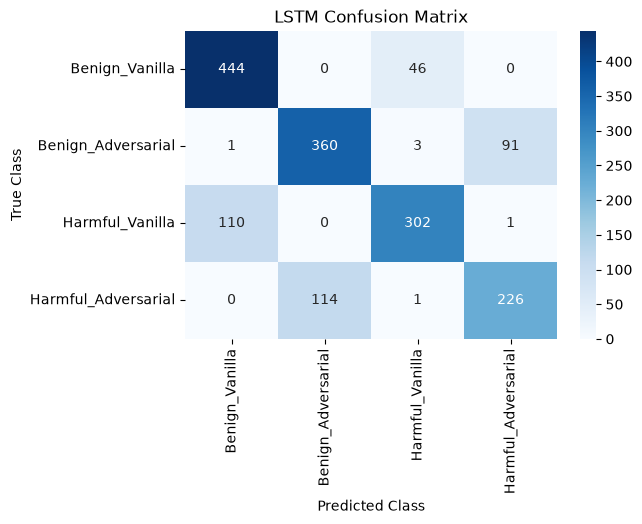


 Bi-SimpleRNN Final Test Evaluation
Test Accuracy: 72.04%
Test Macro F1: 0.7083

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.74      0.93      0.82       490
 Benign_Adversarial       0.70      0.67      0.68       455
    Harmful_Vanilla       0.87      0.61      0.72       413
Harmful_Adversarial       0.59      0.63      0.61       341

           accuracy                           0.72      1699
          macro avg       0.73      0.71      0.71      1699
       weighted avg       0.73      0.72      0.72      1699



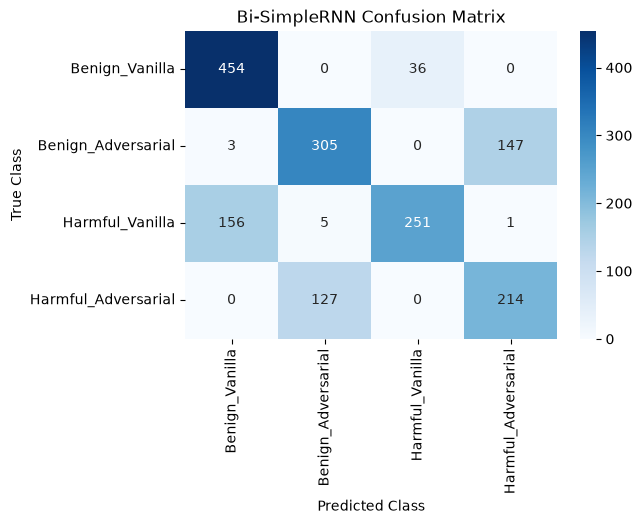


 Bi-GRU Final Test Evaluation
Test Accuracy: 78.69%
Test Macro F1: 0.7766

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.78      0.96      0.86       490
 Benign_Adversarial       0.76      0.79      0.77       455
    Harmful_Vanilla       0.92      0.69      0.78       413
Harmful_Adversarial       0.71      0.67      0.69       341

           accuracy                           0.79      1699
          macro avg       0.79      0.77      0.78      1699
       weighted avg       0.79      0.79      0.78      1699



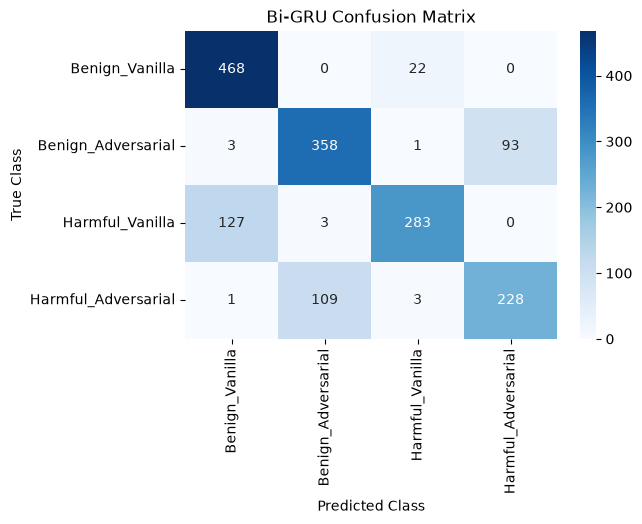


 Bi-LSTM Final Test Evaluation
Test Accuracy: 76.69%
Test Macro F1: 0.7566

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.76      0.94      0.84       490
 Benign_Adversarial       0.75      0.75      0.75       455
    Harmful_Vanilla       0.91      0.65      0.76       413
Harmful_Adversarial       0.68      0.67      0.67       341

           accuracy                           0.77      1699
          macro avg       0.77      0.75      0.76      1699
       weighted avg       0.78      0.77      0.76      1699



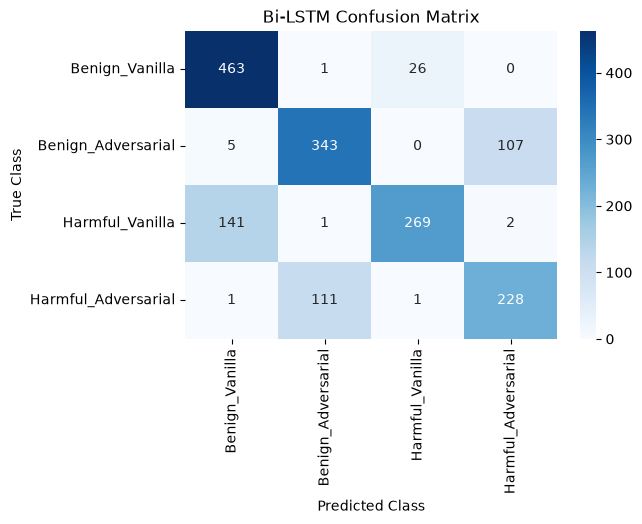

In [58]:
test_results = pd.DataFrame(columns=['Model', 'Test Accuracy', 'Test Macro F1'])
class_names = [TARGET_NAMES[i] for i in range(4)]

for model_name, model in best_models.items():
    print(f"\n==========================================")
    print(f" {model_name} Final Test Evaluation")
    print(f"==========================================")
    
    test_probs = model.predict(X_test_seq, verbose=0)
    test_preds = np.argmax(test_probs, axis=1)
    
    acc = accuracy_score(y_test, test_preds)
    macro_f1 = f1_score(y_test, test_preds, average='macro')
    test_results.loc[len(test_results)] = [model_name, acc, macro_f1]
    
    print(f"Test Accuracy: {acc * 100:.2f}%")
    print(f"Test Macro F1: {macro_f1:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, test_preds, target_names=class_names))
    
    cm = confusion_matrix(y_test, test_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()

 BERT Base Final Test Evaluation 
Test Accuracy: 85.64%
Test Macro F1: 0.8501

Classification Report:
                     precision    recall  f1-score   support

     Benign_Vanilla       0.85      0.98      0.91       490
 Benign_Adversarial       0.83      0.85      0.84       455
    Harmful_Vanilla       0.96      0.79      0.87       413
Harmful_Adversarial       0.79      0.77      0.78       341

           accuracy                           0.86      1699
          macro avg       0.86      0.85      0.85      1699
       weighted avg       0.86      0.86      0.86      1699



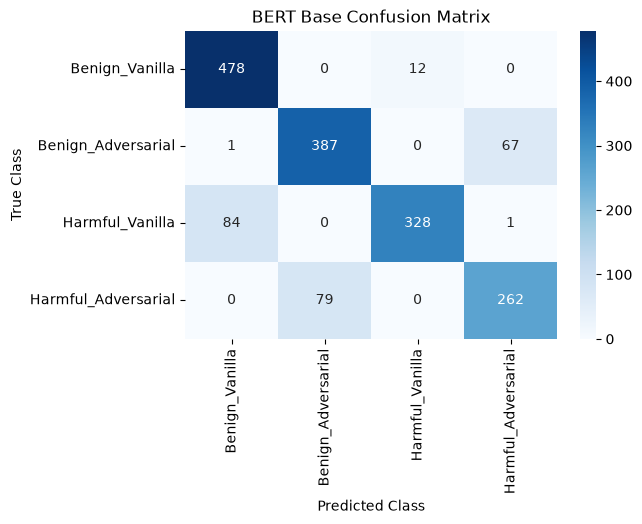

In [60]:
print("==========================================")
print(" BERT Base Final Test Evaluation ")
print("==========================================")
try:
    bert_preds_df = pd.read_csv('BERT Data/bert_predictions.csv')
    test_preds = bert_preds_df['bert_preds'].values
    
    class_names = ['Benign_Vanilla', 'Benign_Adversarial', 'Harmful_Vanilla', 'Harmful_Adversarial']
    
    acc = accuracy_score(y_test, test_preds)
    macro_f1 = f1_score(y_test, test_preds, average='macro')
    
    print(f"Test Accuracy: {acc * 100:.2f}%")
    print(f"Test Macro F1: {macro_f1:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, test_preds, target_names=class_names))
    
    cm = confusion_matrix(y_test, test_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('BERT Base Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()

except FileNotFoundError:
    print("Error: 'bert_predictions.csv' not found.")

### Soft-Voting Ensemble of Top Models (Bonus +2)

To satisfy the bonus objective (*"Implementing an ensemble of the best-performing models and demonstrating improvement"*), we combine the predictions of the top-performing models across three structurally diverse paradigms:
1. **Transformer / Pretrained Language Model**: BERT Base Fine-Tuned
2. **Deep Recurrent Architecture**: Bi-GRU (or top RNN model)
3. **Linear / Discriminative Baseline**: Logistic Regression (TF-IDF with unigrams + bigrams)

By averaging the predicted probability distributions across these diverse model architectures, the ensemble leverages complementary strengths in lexical keyword detection, sequential phrasing, and deep contextual representations.

In [ ]:
print("==========================================")
print(" Soft-Voting Ensemble (BERT + Bi-GRU + Logistic Regression) ")
print("==========================================")

# 1. Logistic Regression Probabilities
lr_probs = lr_model.predict_proba(X_test_tfidf)

# 2. Top Recurrent Model Probabilities (Bi-GRU or GRU)
best_rnn_key = 'Bi-GRU' if 'Bi-GRU' in best_models else ('GRU' if 'GRU' in best_models else list(best_models.keys())[0])
best_rnn_model = best_models[best_rnn_key]
rnn_probs = best_rnn_model.predict(X_test_seq, verbose=0)

# 3. BERT Base Probabilities / One-hot representation
try:
    bert_preds_df = pd.read_csv('BERT Data/bert_predictions.csv')
    if all(f'prob_{i}' in bert_preds_df.columns for i in range(4)):
        bert_probs = bert_preds_df[[f'prob_{i}' for i in range(4)]].values
    elif 'bert_preds' in bert_preds_df.columns:
        bert_probs = np.eye(4)[bert_preds_df['bert_preds'].values]
    else:
        bert_probs = None
except FileNotFoundError:
    bert_probs = None

if bert_probs is not None:
    # Soft-voting: Average predicted class probability distributions
    ensemble_probs = (bert_probs + rnn_probs + lr_probs) / 3.0
    ensemble_preds = np.argmax(ensemble_probs, axis=1)
    
    ens_acc = accuracy_score(y_test, ensemble_preds)
    ens_macro_f1 = f1_score(y_test, ensemble_preds, average='macro')
    
    print(f"Ensemble Test Accuracy: {ens_acc * 100:.2f}%")
    print(f"Ensemble Test Macro F1: {ens_macro_f1:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, ensemble_preds, target_names=class_names))
    
    cm = confusion_matrix(y_test, ensemble_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Soft-Voting Ensemble (BERT + {best_rnn_key} + LR) Confusion Matrix')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()
    
    test_results.loc[len(test_results)] = [f'Soft-Voting Ensemble (BERT + {best_rnn_key} + LR)', ens_acc, ens_macro_f1]
else:
    print("[Warning] BERT predictions not available for ensembling.")

In [61]:
traditional_models = {
    'Naive Bayes': nb_model, 
    'Logistic Regression': lr_model, 
    'Random Forest': rf_model
}

for model_name, model in traditional_models.items():
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average='macro')
    test_results.loc[len(test_results)] = [model_name, acc, macro_f1]
    
try:
    bert_preds_df = pd.read_csv('BERT Data/bert_predictions.csv')
    bert_preds = bert_preds_df['bert_preds'].values
    
    bert_acc = accuracy_score(y_test, bert_preds)
    bert_macro_f1 = f1_score(y_test, bert_preds, average='macro')
    test_results.loc[len(test_results)] = ['BERT Base', bert_acc, bert_macro_f1]
except FileNotFoundError:
    print("\n[Warning] 'bert_predictions.csv' not found. BERT excluded from leaderboard.")

test_results = test_results.drop_duplicates(subset=['Model'], keep='last').reset_index(drop=True)

print("\n==========================================")
print(" Final Test Set Comparison Leaderboard ")
print("==========================================")
display(test_results.sort_values(by='Test Macro F1', ascending=False).reset_index(drop=True))


 Final Test Set Comparison (All 10 Models) 


,Model,Test Accuracy,Test Macro F1
0,BERT Base,0.856386,0.850095
1,GRU,0.790465,0.782763
2,Logistic Regression,0.785168,0.780736
3,Bi-GRU,0.786933,0.776578
4,LSTM,0.783991,0.775054
5,Bi-LSTM,0.766922,0.756555
6,Random Forest,0.738670,0.735295
7,Bi-SimpleRNN,0.720424,0.708257
8,Naive Bayes,0.702766,0.701842
9,SimpleRNN,0.657446,0.648968
